# 绘图
下面的代码主要是为了绘图，也就是paper里面的一些图都是这里生成的，


## 仿真地点演示图
这里主要是演示仿真中，地面站/用户的分布。
中国：
| 地点           | 纬度 (Latitude)  | 经度 (Longitude)  |
| ------------ | -------------- | --------------- |
| 北京           | **39.9042° N** | **116.4074° E** |
| 重庆           | **29.5630° N** | **106.5516° E** |
| 黑龙江（哈尔滨市，省会） | **45.8038° N** | **126.5350° E** |
| 新疆（乌鲁木齐市，首府） | **43.8256° N** | **87.6168° E**  |
| 海南（海口市，省会）   | **20.0442° N** | **110.1999° E** |



欧洲：
| 国家  | 首都            | 纬度 (Latitude)  | 经度 (Longitude) |
| --- | ------------- | -------------- | -------------- |
| 德国  | 柏林 Berlin     | **52.5200° N** | **13.4050° E** |
| 波兰  | 华沙 Warsaw     | **52.2297° N** | **21.0122° E** |
| 法国  | 巴黎 Paris      | **48.8566° N** | **2.3522° E**  |
| 西班牙 | 马德里 Madrid    | **40.4168° N** | **-3.7038° W** |
| 意大利 | 罗马 Rome       | **41.9028° N** | **12.4964° E** |
| 匈牙利 | 布达佩斯 Budapest | **47.4979° N** | **19.0402° E** |


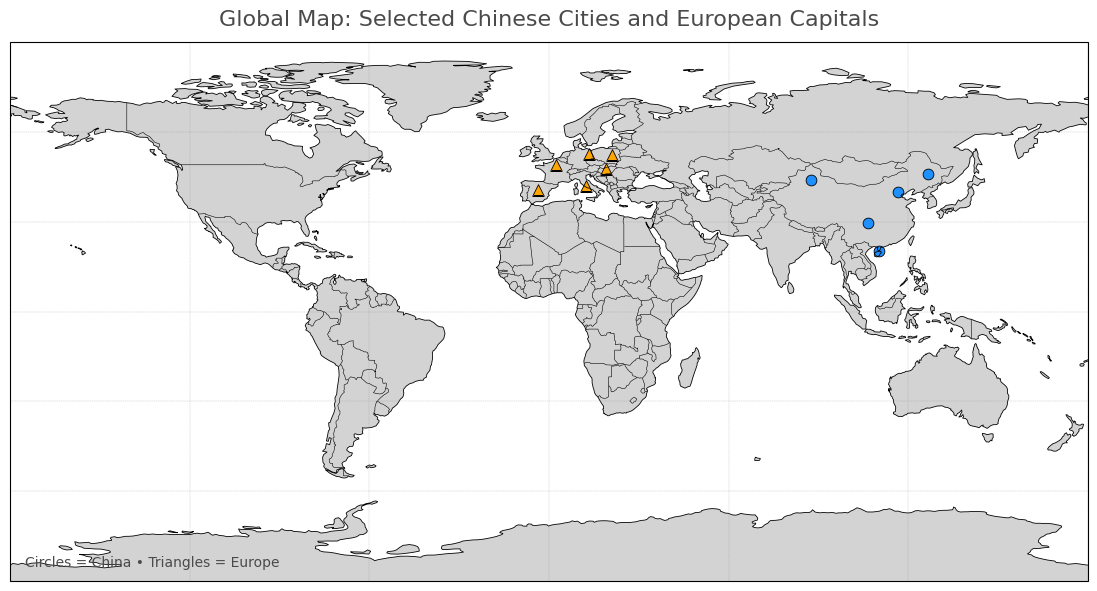

In [5]:
# If needed once: !pip install cartopy matplotlib

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- Data (lat, lon) ----
china_places = {
    "Beijing":        (39.9042, 116.4074),
    "Chongqing":      (29.5630, 106.5516),
    "Heilongjiang":   (45.8038, 126.5350),   # Harbin
    "Xinjiang":       (43.8256, 87.6168),    # Ürümqi
    "Hainan":         (20.0442, 110.1999),   # Haikou
}

europe_capitals = {
    "Germany":   (52.5200, 13.4050),   # Berlin
    "Poland":    (52.2297, 21.0122),   # Warsaw
    "France":    (48.8566, 2.3522),    # Paris
    "Spain":     (40.4168, -3.7038),   # Madrid
    "Italy":     (41.9028, 12.4964),   # Rome
    "Hungary":   (47.4979, 19.0402),   # Budapest
}

# ---- Plot ----
plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

# GLOBAL view
ax.set_global()

# Base map
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)

# Optional gridlines
gl = ax.gridlines(draw_labels=False, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")

# ±50° latitude reference lines
for lat_line in (-50, 50):
    ax.plot([-180, 180], [lat_line, lat_line], transform=ccrs.Geodetic(),
            linewidth=1.0, color="red")

# China markers (circles)
for (_, (lat, lon)) in china_places.items():
    ax.scatter(lon, lat, s=60, marker="o", color="dodgerblue",
               edgecolor="black", linewidths=0.6,
               transform=ccrs.PlateCarree())

# Europe markers (triangles)
for (_, (lat, lon)) in europe_capitals.items():
    ax.scatter(lon, lat, s=70, marker="^", color="orange",
               edgecolor="black", linewidths=0.6,
               transform=ccrs.PlateCarree())

# Overcast-style global title
plt.title("Global Map: Selected Chinese Cities and European Capitals",
          fontsize=16, color="#4A4A4A", pad=12)

# Simple legend text (no per-point labels)
ax.text(-175, -85, "Circles = China • Triangles = Europe",
        fontsize=10, color="#4A4A4A", transform=ccrs.PlateCarree())

plt.show()


参考的效果为下图
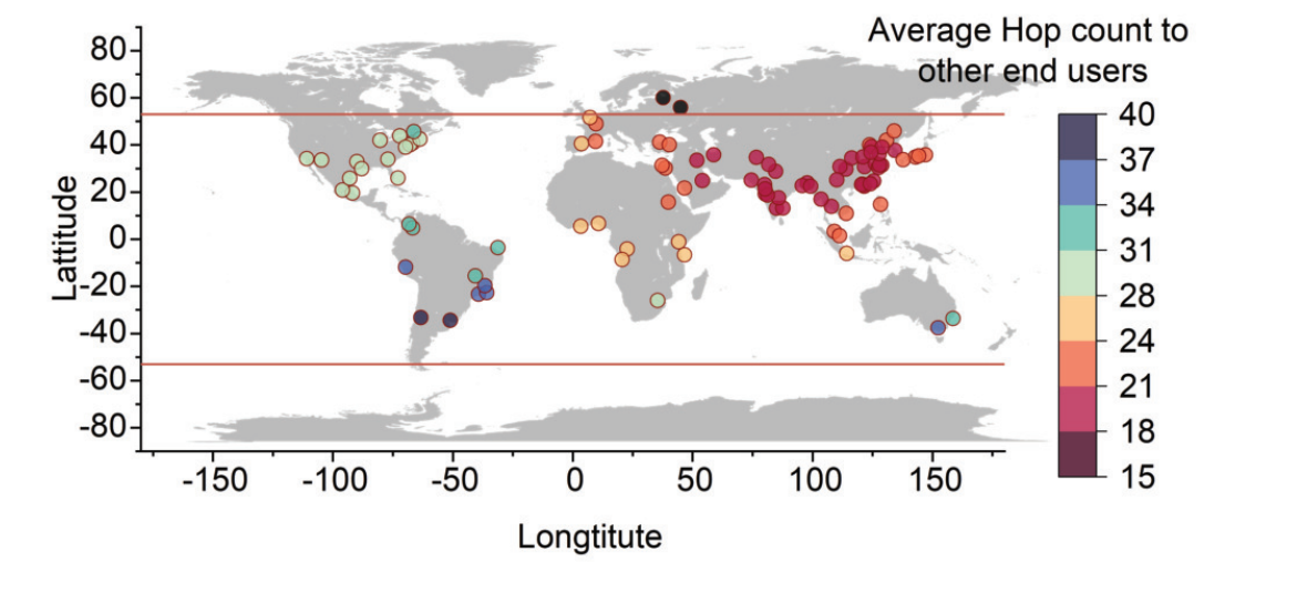

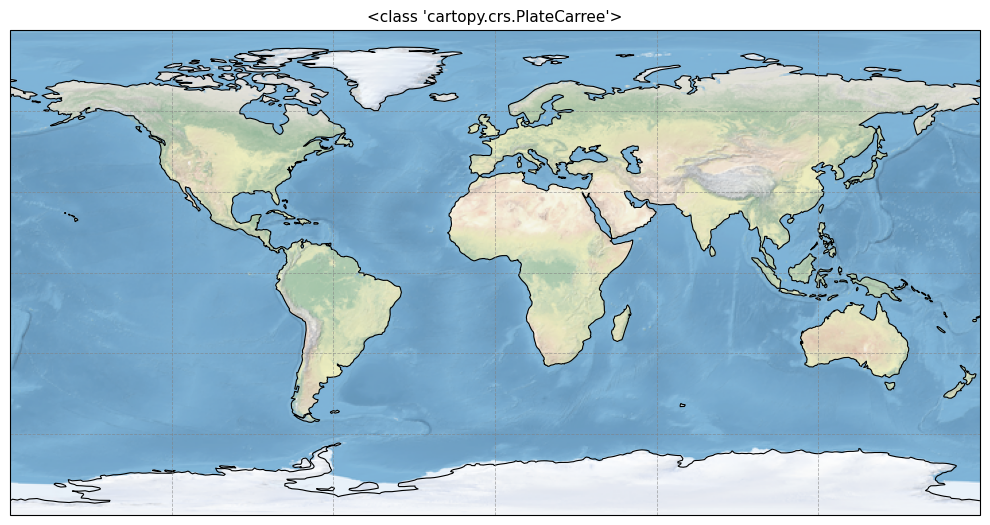

In [31]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig = plt.figure(figsize=(10, 6))
proj = ccrs.PlateCarree()

ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_global()
ax.stock_img()
ax.coastlines(resolution="110m", color="black", linewidth=0.8)
ax.gridlines(draw_labels=False, linestyle="--", color="gray", linewidth=0.6, alpha=0.6)
ax.set_title(str(type(proj)), fontsize=11)

plt.tight_layout()
# —— 导出 —— #
fig.savefig("world_platecarree.pdf", bbox_inches="tight")                 # 矢量，论文首选
fig.savefig("world_platecarree.png", dpi=300, bbox_inches="tight")        # 光栅，300dpi
# fig.savefig("world_platecarree.png", dpi=600, bbox_inches="tight", transparent=True)  # 透明背景可选

plt.show()

上面的图是参考
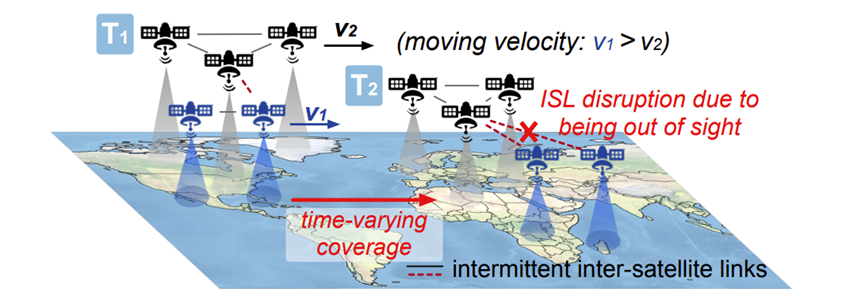